# 02 · İstatistiksel Güç ve Örneklem Büyüklüğü (Power Analysis)
**Statistical Inference Lab**

---
> **Bu notebook'ta ne öğreneceğiz?**  
> 01'de (Hipotez Testi) Tip II Hatayı ($\beta$ — gerçek bir etkiyi kaçırma olasılığı) tanımlamış
> ama detaylandırmamıştık. Bu notebook'ta $\beta$'nın tersi olan **istatistiksel güç**
> ($1-\beta$) kavramına giriyoruz — ve daha da önemlisi, bir deneyi **yapmadan önce** "kaç
> kişiye/örneğe ihtiyacım var" sorusuna cevap veren **örneklem büyüklüğü hesabını**
> öğreneceğiz. Bu, iyi tasarlanmış her deneyin (A/B testi, klinik çalışma) veri toplamadan ÖNCE yapması gereken bir hesap.

**Önkoşul:** Hipotez Testi (01), Normal Dağılım (`probability-lab` 03a)  
**Veri:**  
- `diabetes.csv` — Pima Indians Diabetes (768 hasta, glukoz seviyesi ve diyabet durumu)  
**Araçlar:** Python (`statsmodels.stats.power`), R (base R `power.t.test`)

---
## 1 · Güç Nedir? 01'deki Tip II Hatanın Tersi

01'deki tabloyu hatırla:

| | Gerçekte $H_0$ Doğru | Gerçekte $H_0$ Yanlış |
|---|---|---|
| Testin Kararı: Reddet | Tip I Hata (α) | ✅ **Doğru Karar (GÜÇ)** |
| Testin Kararı: Reddetme | ✅ Doğru Karar | Tip II Hata (β) |

**İstatistiksel Güç** ($1-\beta$): *"Eğer gerçekten bir etki/fark varsa, testimin bunu
yakalama olasılığı."* Güç düşükse (örn. %40), gerçek bir etki olsa bile deneyinin bunu
**kaçırma ihtimali** yüksek demektir — "sonuç anlamsız çıktı" dediğinde, aslında etki hiç
yok muydu, yoksa deneyin zayıf mıydı, bilemezsin.

**Endüstri standardı:** Güç için genelde $1-\beta = 0.80$ (%80) hedeflenir — yani gerçek bir
etkiyi %80 ihtimalle yakalayacak kadar büyük bir deney tasarlamak.

---
## 2 · Etki Büyüklüğü (Effect Size): Cohen's d

p-value'nun söylemediği bir şey var: **farkın pratikte ne kadar büyük olduğu.** Çok büyük bir
örneklemde (n=1.000.000), anlamsız derecede küçük bir fark bile "istatistiksel olarak anlamlı"
çıkabilir. Effect size, bu boşluğu dolduruyor — farkın **standart sapmalar cinsinden büyüklüğünü** ölçüyor:

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{havuzlanmış}}}$$

**Cohen'in (1988) kaba kuralı:**

| $\|d\|$ | Yorum |
|---|---|
| 0.2 | Küçük etki |
| 0.5 | Orta etki |
| 0.8+ | Büyük etki |

Bu sayı, 01'deki $t$-istatistiğine çok benziyor ama **örneklem büyüklüğünden bağımsız** —
$t$, $n$ arttıkça büyür (aynı fark daha "kesin" hale gelir), ama $d$ sabit kalır (farkın
kendisi değişmedi, sadece ona olan güvenimiz arttı).

---
## 3 · Dörtlü İlişki: Güç, n, Etki Büyüklüğü, α

Bu dört büyüklük birbirine bağlı — **herhangi 3'ünü bilirsen 4.'yü hesaplayabilirsin**:

$$\text{Güç} = f(n, d, \alpha)$$

- $n$ artarsa → Güç artar (daha çok veri, daha kesin sonuç)
- $d$ artarsa (etki daha büyükse) → Güç artar (büyük farkları yakalamak kolay)
- $\alpha$ artarsa (daha gevşek eşik) → Güç artar (ama Tip I Hata riski de artar — bir bedeli var)

**En yaygın kullanım:** Güç ($0.80$), $d$ (literatürden veya pilot çalışmadan tahmin), ve
$\alpha$ ($0.05$) sabitlenir, **gereken $n$ çözülür.** Bu, "deneyi tasarlarken kaç örnek
toplamalıyım" sorusunun cevabı.

---
## 4 · Neden ÖNCEDEN Hesaplanmalı? "Post-Hoc Power" Tartışması

İki farklı senaryo var, ve aralarındaki fark kritik:

- **A Priori (Önceden) Güç Analizi:** Deneyi tasarlarken, "bu etkiyi %80 güçle yakalamak için
  kaç örnek gerekiyor" diye SORU sorup buna göre veri topluyorsun. Bu **doğru ve standart pratik.**
- **Post-Hoc (Sonradan) Güç Analizi:** Deney bitti, sonuç "anlamsız" çıktı, sonra "acaba
  gücüm yeterli miydi" diye geriye dönük hesaplıyorsun. Bu yaklaşım istatistikçiler arasında
  **tartışmalı** — çünkü post-hoc güç, gözlemlenen p-value ile matematiksel olarak birebir
  bağlantılı bir sayı üretiyor (yeni bilgi vermiyor, sadece p-value'yu başka bir formatta tekrarlıyor).

Bu notebook'ta ağırlıklı olarak **a priori** (önceden) güç analizine odaklanacağız — bu,
gerçek dünyada asıl kullanılması gereken yaklaşım.

---
# 🐍 Python Uygulaması

3 adımda ilerleyeceğiz:
1. **Cohen's d Hesaplama** — Diyabetli/değil gruplarında glukoz farkının etki büyüklüğü
2. **Gerekli Örneklem Büyüklüğü** — Bu etkiyi %80 güçle yakalamak için kaç kişi gerekirdi?
3. **Güç Eğrisi** — n arttıkça gücün nasıl arttığını görselleştirme

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.power import tt_ind_solve_power

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🩺 Python 1 — Cohen's d: Diyabetli/Değil Gruplarında Glukoz Farkı

**Ne yapıyoruz?**  
`Glucose` sütununda 0 değerleri gerçek ölçüm değil, eksik veri işareti (bilinen bir veri
kalitesi sorunu bu veri setinde) — önce bunları temizleyip, sonra iki grubun glukoz farkının
Cohen's d'sini hesaplıyoruz.

Ham veri: 768 hasta
Temizlik sonrası (Glucose>0): 763 hasta

Diyabetli: n=266, ortalama=142.32, std=29.60
Sağlıklı:  n=497, ortalama=110.64, std=24.78

Cohen's d: 1.1928
Yorum: Büyük bir etki büyüklüğü (Cohen'in kaba kuralına göre)

Welch t-test: t=14.8844, p=2.84e-41 (istatistiksel olarak anlamlı)
NOT: p çok küçük çıkıyor (n=768 zaten oldukça büyük) ama Cohen's d bize farkın
PRATİKTE ne kadar büyük olduğunu ayrıca söylüyor - ikisi farklı sorulara cevap veriyor.


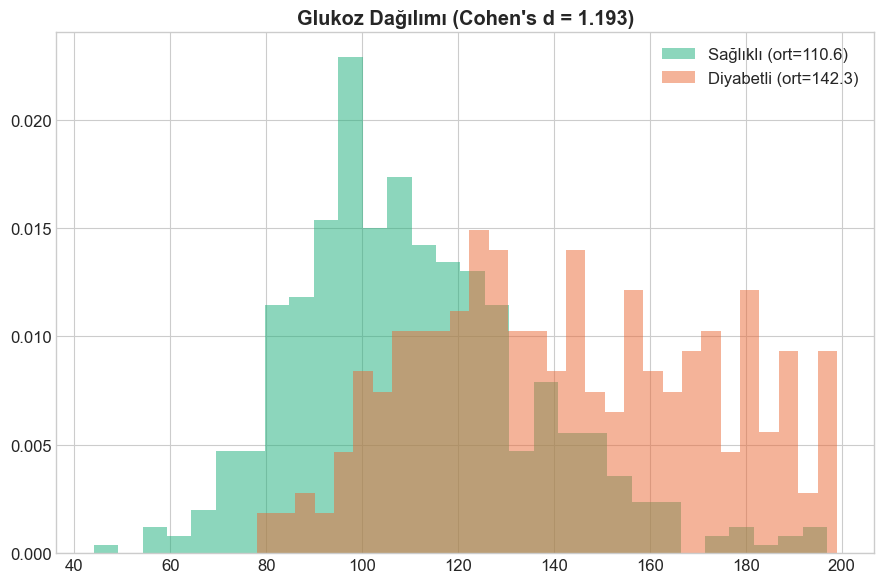

In [2]:
diabetes = pd.read_csv('data/diabetes.csv')
print(f"Ham veri: {diabetes.shape[0]} hasta")

diabetes_temiz = diabetes[diabetes['Glucose'] > 0]
print(f"Temizlik sonrası (Glucose>0): {diabetes_temiz.shape[0]} hasta")

diyabetli = diabetes_temiz[diabetes_temiz['Outcome'] == 1]['Glucose']
saglikli = diabetes_temiz[diabetes_temiz['Outcome'] == 0]['Glucose']

print(f"\nDiyabetli: n={len(diyabetli)}, ortalama={diyabetli.mean():.2f}, std={diyabetli.std():.2f}")
print(f"Sağlıklı:  n={len(saglikli)}, ortalama={saglikli.mean():.2f}, std={saglikli.std():.2f}")

def cohens_d(grup1, grup2):
    n1, n2 = len(grup1), len(grup2)
    s1, s2 = grup1.std(ddof=1), grup2.std(ddof=1)
    havuzlanmis_std = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return (grup1.mean() - grup2.mean()) / havuzlanmis_std

d = cohens_d(diyabetli, saglikli)
print(f"\nCohen's d: {d:.4f}")
yorum = "Küçük" if abs(d) < 0.5 else ("Orta" if abs(d) < 0.8 else "Büyük")
print(f"Yorum: {yorum} bir etki büyüklüğü (Cohen'in kaba kuralına göre)")

# t-test ile karsilastirma (01'deki bilgiyi hatirlayalim)
t_ist, p_val = stats.ttest_ind(diyabetli, saglikli, equal_var=False)
print(f"\nWelch t-test: t={t_ist:.4f}, p={p_val:.2e} (istatistiksel olarak anlamlı)")
print("NOT: p çok küçük çıkıyor (n=768 zaten oldukça büyük) ama Cohen's d bize farkın")
print("PRATİKTE ne kadar büyük olduğunu ayrıca söylüyor - ikisi farklı sorulara cevap veriyor.")

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(saglikli, bins=30, alpha=0.5, color='#1baf7a', label=f'Sağlıklı (ort={saglikli.mean():.1f})', density=True)
ax.hist(diyabetli, bins=30, alpha=0.5, color='#eb6834', label=f'Diyabetli (ort={diyabetli.mean():.1f})', density=True)
ax.set_title(f"Glukoz Dağılımı (Cohen's d = {d:.3f})", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
### 📏 Python 2 — Gerekli Örneklem Büyüklüğü: Bu Etkiyi Yakalamak İçin Kaç Kişi Gerekirdi?

**Ne yapıyoruz?**  
Bölüm 1'de bulduğumuz Cohen's d'yi kullanarak, **geriye dönük** olarak soruyoruz: "Bu etki
büyüklüğünü %80 güçle yakalamak için minimum kaç kişiye ihtiyacım vardı?" — sonra bunu
GERÇEKTE kullandığımız n (768) ile karşılaştırıyoruz.

In [3]:
analiz = TTestIndPower() # statsmodels ile güç analizi

gereken_n = analiz.solve_power(effect_size=d, alpha=0.05, power=0.80, alternative='two-sided')
print(f"Cohen's d={d:.4f} etkisini %80 güçle yakalamak için GRUP BAŞINA gereken n: {gereken_n:.1f}")
print(f"Gerçekte kullandığımız n: diyabetli={len(diyabetli)}, sağlıklı={len(saglikli)}")

if min(len(diyabetli), len(saglikli)) > gereken_n:
    print(f"\n✓ Gerçek örneklem büyüklüğümüz gereken minimumun ÜZERİNDE - deney yeterince güçlüydü.")
else:
    print(f"\n✗ Gerçek örneklem büyüklüğümüz gereken minimumun ALTINDA - deney yetersiz güçlü olabilirdi.")

# Farkli etki buyuklukleri icin gereken n karsilastirmasi
print("\n=== Farklı Etki Büyüklükleri İçin Gereken Örneklem Büyüklüğü (Güç=0.80, α=0.05) ===")
for d_test in [0.2, 0.5, 0.8, d]:
    n_gerekli = analiz.solve_power(effect_size=d_test, alpha=0.05, power=0.80, alternative='two-sided')
    etiket = f"(bizim glukoz örneğimiz: d={d:.3f})" if d_test == d else ""
    print(f"d={d_test:.3f}: n={n_gerekli:.1f} kişi/grup {etiket}")

print("\nYORUM: Etki küçüldükçe (d=0.2 gibi 'küçük' bir fark), onu güvenle yakalamak için")
print("ÇOK daha fazla veriye ihtiyaç duyuyorsun - küçük etkileri tespit etmek 'pahalı'.")

Cohen's d=1.1928 etkisini %80 güçle yakalamak için GRUP BAŞINA gereken n: 12.1
Gerçekte kullandığımız n: diyabetli=266, sağlıklı=497

✓ Gerçek örneklem büyüklüğümüz gereken minimumun ÜZERİNDE - deney yeterince güçlüydü.

=== Farklı Etki Büyüklükleri İçin Gereken Örneklem Büyüklüğü (Güç=0.80, α=0.05) ===
d=0.200: n=393.4 kişi/grup 
d=0.500: n=63.8 kişi/grup 
d=0.800: n=25.5 kişi/grup 
d=1.193: n=12.1 kişi/grup (bizim glukoz örneğimiz: d=1.193)

YORUM: Etki küçüldükçe (d=0.2 gibi 'küçük' bir fark), onu güvenle yakalamak için
ÇOK daha fazla veriye ihtiyaç duyuyorsun - küçük etkileri tespit etmek 'pahalı'.


---
### 📈 Python 3 — Güç Eğrisi: n ve Etki Büyüklüğü Birlikte Değişince

**Ne yapıyoruz?**  
Farklı örneklem büyüklükleri ($n$) ve farklı etki büyüklükleri ($d$) için gücün nasıl
değiştiğini tek bir grafikte gösteriyoruz — "daha fazla veri her zaman daha çok güç" ilişkisinin
görsel kanıtı, ayrıca küçük etkilerin neden daha "pahalı" olduğunu da gösteriyor.

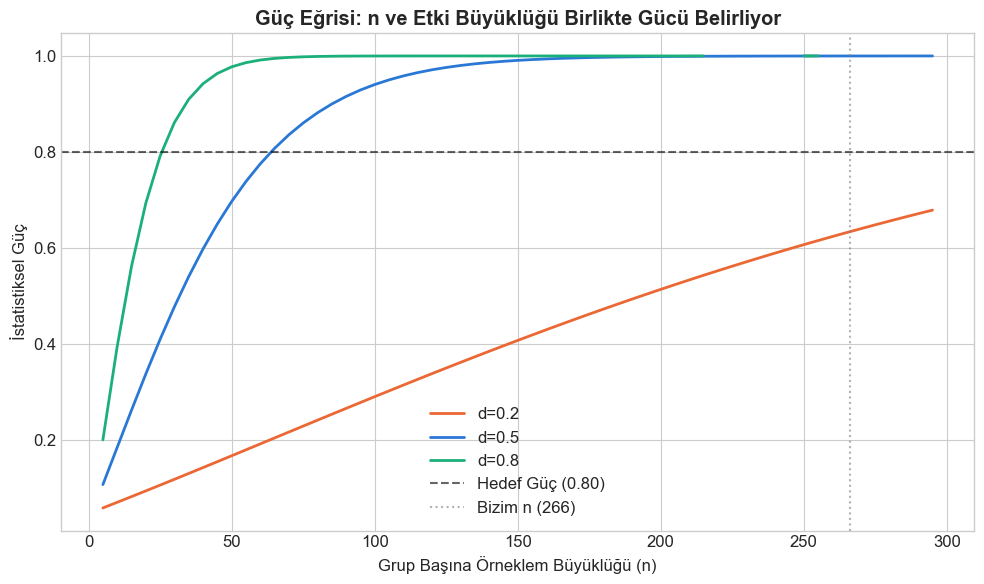

YORUM: d=0.8 (büyük etki) için güç çok hızlı %80'e ulaşıyor - az veriyle bile
yakalanabiliyor. d=0.2 (küçük etki) için ise eğri çok daha yavaş yükseliyor -
aynı güce ulaşmak için çok daha fazla n gerekiyor. Bu üçlü eğri, Bölüm 3'teki
'dörtlü ilişkinin' tek bir görselde özeti.


In [4]:
n_range = np.arange(5, 300, 5)
etki_buyuklukleri = [0.2, 0.5, 0.8]
renkler = ['#eb6834', '#2a78d6', '#1baf7a']

fig, ax = plt.subplots(figsize=(10, 6))
for d_val, renk in zip(etki_buyuklukleri, renkler):
    guc_degerleri = [analiz.solve_power(effect_size=d_val, nobs1=n, alpha=0.05, alternative='two-sided')
                     for n in n_range]
    ax.plot(n_range, guc_degerleri, color=renk, linewidth=2, label=f'd={d_val}')

ax.axhline(0.80, color='black', linestyle='--', alpha=0.6, label='Hedef Güç (0.80)')
ax.axvline(min(len(diyabetli), len(saglikli)), color='gray', linestyle=':', alpha=0.6,
           label=f'Bizim n ({min(len(diyabetli), len(saglikli))})')
ax.set_xlabel('Grup Başına Örneklem Büyüklüğü (n)')
ax.set_ylabel('İstatistiksel Güç')
ax.set_title('Güç Eğrisi: n ve Etki Büyüklüğü Birlikte Gücü Belirliyor', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: d=0.8 (büyük etki) için güç çok hızlı %80'e ulaşıyor - az veriyle bile")
print("yakalanabiliyor. d=0.2 (küçük etki) için ise eğri çok daha yavaş yükseliyor -")
print("aynı güce ulaşmak için çok daha fazla n gerekiyor. Bu üçlü eğri, Bölüm 3'teki")
print("'dörtlü ilişkinin' tek bir görselde özeti.")

---
# 📊 R Uygulaması

R'ın **base R'a yerleşik** (`stats` paketi, hiçbir ek kurulum gerekmez) `power.t.test()`
fonksiyonu, Python'daki `statsmodels` çağrılarının hepsini karşılıyor — `n`, `power`, `delta`
argümanlarından birini boş bırakırsan R onu senin için çözüyor.

In [5]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🩺 R 1 — Cohen's d ve Mevcut Gücün Hesabı

**Yeni R kavramı:** `power.t.test()` içinde `power=NULL` bırakıp `n=` vermek, "bu n ile
gücüm ne kadar" sorusuna cevap veriyor (Python 1'in devamı niteliğinde).

In [6]:
%%R -i diabetes_temiz -w 900 -h 550

diyabetli_r <- diabetes_temiz[diabetes_temiz$Outcome == 1, ]$Glucose
saglikli_r <- diabetes_temiz[diabetes_temiz$Outcome == 0, ]$Glucose

n1 <- length(diyabetli_r); n2 <- length(saglikli_r)
s1 <- sd(diyabetli_r); s2 <- sd(saglikli_r)
havuzlanmis_std <- sqrt(((n1-1)*s1^2 + (n2-1)*s2^2) / (n1+n2-2))
d_r <- (mean(diyabetli_r) - mean(saglikli_r)) / havuzlanmis_std

cat("Cohen's d (R'da hesaplanan):", d_r, "\n")
cat("Python'daki d ile karşılaştır - birebir örtüşmeli.\n\n")

# Mevcut n ile gucumuz ne kadardi?
sonuc_guc <- power.t.test(n = min(n1, n2), delta = mean(diyabetli_r) - mean(saglikli_r),
                            sd = havuzlanmis_std, sig.level = 0.05, type = "two.sample")
print(sonuc_guc)

Cohen's d (R'da hesaplanan): 1.192801 
Python'daki d ile karşılaştır - birebir örtüşmeli.


     Two-sample t test power calculation 

              n = 266
          delta = 31.67569
             sd = 26.55572
      sig.level = 0.05
          power = 1
    alternative = two.sided

NOTE: n is number in *each* group



---
### 📏 R 2 — Gerekli Örneklem Büyüklüğü

**Yeni R kavramı:** Aynı `power.t.test()` fonksiyonunda bu sefer `n=NULL` bırakıp `power=0.80`
vermek — Python 2'deki `solve_power(power=0.80)` çağrısının R karşılığı.

In [7]:
%%R

# d cinsinden calismak icin delta=d, sd=1 verebiliriz (standardize edilmis etki buyuklugu)
for (d_test in c(0.2, 0.5, 0.8)) {
  sonuc <- power.t.test(delta = d_test, sd = 1, power = 0.80, sig.level = 0.05, type = "two.sample")
  cat(sprintf("d=%.1f icin gereken n (grup basina): %.1f\n", d_test, sonuc$n))
}

cat("\nBizim glukoz ornegimizin d degeri icin:\n")
sonuc_bizim <- power.t.test(delta = d_r, sd = 1, power = 0.80, sig.level = 0.05, type = "two.sample")
cat(sprintf("d=%.4f icin gereken n: %.1f\n", d_r, sonuc_bizim$n))
cat("Python 2'deki 'gereken_n' degeriyle karsilastir - birebir ortusmeli.\n")

d=0.2 icin gereken n (grup basina): 393.4
d=0.5 icin gereken n (grup basina): 63.8
d=0.8 icin gereken n (grup basina): 25.5

Bizim glukoz ornegimizin d degeri icin:
d=1.1928 icin gereken n: 12.1
Python 2'deki 'gereken_n' degeriyle karsilastir - birebir ortusmeli.


---
### 📈 R 3 — Güç Eğrisi

**Yeni R kavramı yok** — `sapply()` ile bir döngü, Python 3'teki liste comprehension'ın
R karşılığı.

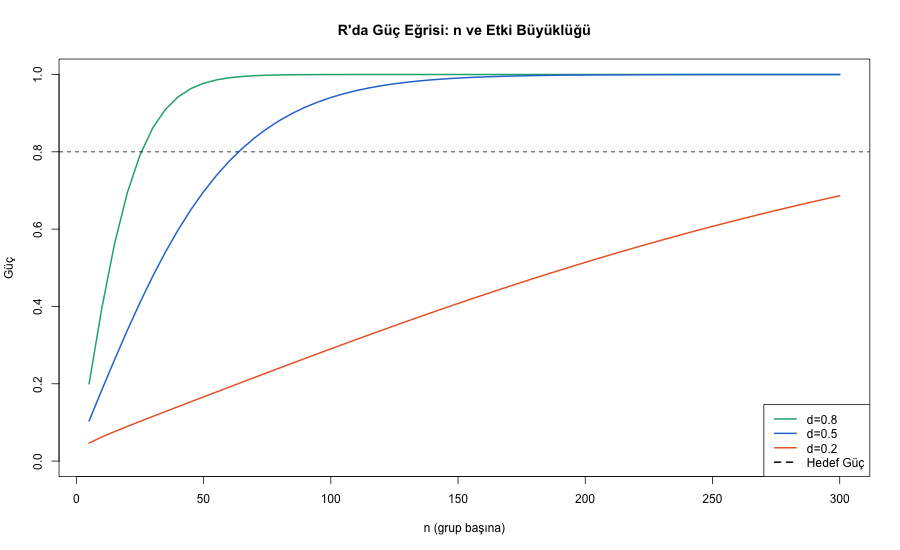

In [8]:
%%R -w 900 -h 550

n_range_r <- seq(5, 300, by = 5)

guc_02 <- sapply(n_range_r, function(n) power.t.test(n=n, delta=0.2, sd=1, sig.level=0.05)$power)
guc_05 <- sapply(n_range_r, function(n) power.t.test(n=n, delta=0.5, sd=1, sig.level=0.05)$power)
guc_08 <- sapply(n_range_r, function(n) power.t.test(n=n, delta=0.8, sd=1, sig.level=0.05)$power)

plot(n_range_r, guc_08, type = "l", col = "#1baf7a", lwd = 2, ylim = c(0, 1),
     main = "R'da Güç Eğrisi: n ve Etki Büyüklüğü", xlab = "n (grup başına)", ylab = "Güç")
lines(n_range_r, guc_05, col = "#2a78d6", lwd = 2)
lines(n_range_r, guc_02, col = "#eb6834", lwd = 2)
abline(h = 0.80, col = "black", lty = 2)
legend("bottomright", legend = c("d=0.8", "d=0.5", "d=0.2", "Hedef Güç"),
       col = c("#1baf7a", "#2a78d6", "#eb6834", "black"), lty = c(1,1,1,2), lwd = 2)

---
## ✏️ Egzersizler

### **E1 (Python).** 
`diabetes.csv`'de `BMI` sütunu için diyabetli/sağlıklı gruplarının Cohen's
d'sini hesapla. Glukoz'a kıyasla etki büyüklüğü daha mı küçük, daha mı büyük? Bu iki
değişkenden hangisi diyabeti "daha güçlü ayırt ediyor"?

In [10]:
print("\n ==== Egzersiz 1: Diyabetli ve Sağlıklı Bireylerde BMI Analizi ====")

diyabetli_bmi = diabetes_temiz[diabetes_temiz['Outcome'] == 1]['BMI']
saglikli_bmi = diabetes_temiz[diabetes_temiz['Outcome'] == 0]['BMI']

print(f"Diyabetli: n={len(diyabetli_bmi)}, ortalama={diyabetli_bmi.mean():.2f}, std={diyabetli_bmi.std():.2f}")
print(f"Sağlıklı:  n={len(saglikli_bmi)}, ortalama={saglikli_bmi.mean():.2f}, std={saglikli_bmi.std():.2f}")

d = cohens_d(diyabetli_bmi, saglikli_bmi)
print(f"\nCohen's d: {d:.4f}")
yorum = "Küçük" if abs(d) < 0.5 else ("Orta" if abs(d) < 0.8 else "Büyük")
print(f"Yorum: {yorum} bir etki büyüklüğü (Cohen'in kaba kuralına göre)")

t_ist, p_val = stats.ttest_ind(diyabetli_bmi, saglikli_bmi, equal_var=False)
print(f"\nWelch t-test: t={t_ist:.4f}, p={p_val:.2e} (istatistiksel olarak anlamlı)")


 ==== Egzersiz 1: Diyabetli ve Sağlıklı Bireylerde BMI Analizi ====
Diyabetli: n=266, ortalama=35.11, std=7.28
Sağlıklı:  n=497, ortalama=30.32, std=7.71

Cohen's d: 0.6334
Yorum: Orta bir etki büyüklüğü (Cohen'in kaba kuralına göre)

Welch t-test: t=8.4834, p=1.89e-16 (istatistiksel olarak anlamlı)


---

### **E2 (Python).**
`Age` değişkeni için aynı analizi tekrarla, ardından `TTestIndPower` ile
bu etkiyi %90 güçle (daha sıkı bir hedef) yakalamak için gereken örneklem büyüklüğünü
hesapla — %80 hedefine göre ne kadar daha fazla veri gerekiyor?

In [12]:
print("\n ==== Egzersiz 2: Diyabetli ve Sağlıklı Bireylerde Yaş Analizi ====")

diyabetli_yas = diabetes_temiz[diabetes_temiz['Outcome'] == 1]['Age']
saglikli_yas = diabetes_temiz[diabetes_temiz['Outcome'] == 0]['Age']

d_age = cohens_d(diyabetli_yas, saglikli_yas)
print(f"\nCohen's d (Yaş): {d_age:.4f}")

gereken_n_age_90 = analiz.solve_power(effect_size=d_age, alpha=0.05, power=0.90, alternative='two-sided')
print(f"Cohen's d={d_age:.4f} etkisini %90 güçle yakalamak için GRUP BAŞINA gereken n: {gereken_n_age_90:.1f}")

gereken_n_age_80 = analiz.solve_power(effect_size=d_age, alpha=0.05, power=0.80, alternative='two-sided')
print(f"Cohen's d={d_age:.4f} etkisini %80 güçle yakalamak için GRUP BAŞINA gereken n: {gereken_n_age_80:.1f}")


 ==== Egzersiz 2: Diyabetli ve Sağlıklı Bireylerde Yaş Analizi ====

Cohen's d (Yaş): 0.5070
Cohen's d=0.5070 etkisini %90 güçle yakalamak için GRUP BAŞINA gereken n: 82.7
Cohen's d=0.5070 etkisini %80 güçle yakalamak için GRUP BAŞINA gereken n: 62.0


---

### **E3 (Python).**
Kendi tasarladığın hayali bir A/B testi senaryosu için (örn. "yeni
arayüz, dönüşüm oranını %2 artıracak") önce beklediğin etki büyüklüğünü tahmin et, sonra
gereken örneklem büyüklüğünü **hem Python'da hem R'da** hesaplayıp karşılaştır.

### A/B Testi

- Mevcut e-Ticaret sitesinde ödeme sayfasının tasarımını yeniledik diyelim ve dönüşüm oranını arttıralım:
    * Mevcut Durumda (Kontrol) = Dönüşüm Oranı %22 ($p_1 = 0.22$)
    * Hedeflenen Durum (Varyant) = Dönüşümde %4 artış ($p_2 = 0.26$)
    * *Kabul Edilen Parametreler $\alpha = 0.05, (1-\beta) = 0.80$

> Cohen's d yerine Cohen's h kullanacağız. Fark olarak iki oranın ark sinüs dönüşümlerinin farkını alır

$$h = 2 \times (\text{arcsin}(\sqrt(p_2)) - \text{arcsin}(\sqrt(p_2))$$

In [22]:
print("\n ==== Egzersiz 3: A/B Testi için Etki ve Örneklem Büyüklüğü ====")

from statsmodels.stats.power import NormalIndPower

# A/B testi için örneklem büyüklüğü hesaplaması
p_1 = 0.22 # Kontrol grubu oranı
p_2 = 0.26 # Test grubu oranı

# Cohen's h hesaplaması
h = 2 * np.arcsin(np.sqrt(p_2)) - 2 * np.arcsin(np.sqrt(p_1))
print(f"Cohen's h: {h:.4f}")

# Örneklem büyüklüğü hesaplaması
power_analysis = NormalIndPower()
required_n = power_analysis.solve_power(effect_size=h, alpha=0.05, power=0.80, alternative='two-sided')
print(f"Gerekli örneklem büyüklüğü (grup başına): {required_n:.1f}")


 ==== Egzersiz 3: A/B Testi için Etki ve Örneklem Büyüklüğü ====
Cohen's h: 0.0937
Gerekli örneklem büyüklüğü (grup başına): 1786.8


---

### **E4 (R).**
`power.t.test()`'i `sig.level` (α) değerini 0.05 yerine 0.01 yaparak tekrarla 
daha sıkı bir Tip I Hata eşiği, gereken örneklem büyüklüğünü nasıl etkiliyor? 

In [21]:
%%R

cat("\n ==== Egzersiz 4: Sig Level Seviyesine Göre Örneklem Büyüklüğü ====")

for (sigl in c(0.01, 0.05)) {
    sonuc_sigma <- power.t.test(delta = 0.5, sd = 1 , power = 0.80, sig.level = sigl, type = "two.sample")
    cat(sprintf("\nSig level=%.2f icin gereken n: %.1f\n", sigl, sonuc_sigma$n))
}

cat("\nYORUM: sig level'ı azaltırsak gücü aynı tutmak için daha fazla örneklem büyüklüğüne ihtiyaç duyuyoruz - bu mantıklı, çünkü daha düşük sig level, daha güçlü testler gerektirir.")


 ==== Egzersiz 4: Sig Level Seviyesine Göre Örneklem Büyüklüğü ====
Sig level=0.01 icin gereken n: 95.1

Sig level=0.05 icin gereken n: 63.8

YORUM: sig level'ı azaltırsak gücü aynı tutmak için daha fazla örneklem büyüklüğüne ihtiyaç duyuyoruz - bu mantıklı, çünkü daha düşük sig level, daha güçlü testler gerektirir.

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 10 | Hipotez testi ve güç kavramı |
| [Cohen, J. (1988) — Statistical Power Analysis](https://www.utstat.toronto.edu/~brunner/oldclass/378f16/readings/CohenPower.pdf) | — | Effect size sınıflandırmasının orijinal kaynağı |
| [statsmodels Power Analysis Dokümantasyonu](https://www.statsmodels.org/stable/stats.html#power-and-sample-size-calculations) | Kütüphane | Bu notebook'ta kullanılan ana araç |
| [Seeing Theory](https://seeing-theory.brown.edu/frequentist-inference) | Frequentist Inference | İnteraktif — Tip I/II hata ve güç |
| [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) | Veri | diabetes.csv kaynağı |
| R `power.t.test()` dokümantasyonu | Base R (`?power.t.test`) | R'daki ana araç, ek paket gerekmez |